# Frontier: PLAN 09 actual overlap neighborhoods

This notebook is the live frontier notebook for PLAN 09. Its purpose is **not** to restate only an abstract theorem surface. Its purpose is to build a concrete **construction skeleton** for the actual overlap neighborhoods by starting from one explicit numerical example and extracting the exact recipe that a genuine proof must follow. What remains missing after this notebook is no longer the sandbox recipe itself, but its **theorem-level / Lean instantiation for the genuine high-escaping curve**.

Since the first version of this notebook, the theorem-facing proof skeletons described here have now been formalized in Lean in `ConstructiveBasinCoordinate.lean`: explicit overlap-neighborhood data, chain-level equality-on-overlap data, and the high-escaping packaging layer now exist as checked theorem surfaces. The missing part is still the genuine geometric existence/construction theorem that supplies those packages for the actual high-escaping curve.

The older Step 13 counterexample and weakened-theorem status notebook remains archived at `notebooks/archive/plan08_step13_actual_high_escaping_charts_frontier.ipynb`. The comparison frontier is still recorded separately in `notebooks/plan08_step13_overlap_comparison_frontier.ipynb`.


## Acceptance criteria for this notebook

This notebook is accepted only if it contains the following six items in order:

1. **Input geometry:** start from one actual high-level curve $A_K([0,1])$ in a worked numerical example.
2. **Chart recipe:** give an explicit rule for choosing charts $U_j$ from short image segments.
3. **Overlap recipe:** give an explicit rule for choosing interior overlaps $V_j \subset U_j \cap U_{j+1}$ and a closing overlap $V_{\mathrm{cl}} \subset U_m \cap U_0$.
4. **Branch recipe:** give an explicit construction of local logarithm branches $b_j$ by continuation from the normalized base germ.
5. **Proof obligations:** list the concrete lemmas that the genuine proof must establish:
   - segment containment in $U_j$,
   - overlap windows inside $V_j$,
   - closing window inside $V_{\mathrm{cl}}$,
   - equality of adjacent branches on $V_j$,
   - equality of terminal and initial branches on $V_{\mathrm{cl}}$.
6. **Special-case sandbox:** carry out all five steps explicitly in one worked numerical example and explain how that recipe should be generalized to the genuine proof.


## Worked numerical example: one high-level curve first

We begin with one concrete special case and make the construction completely explicit.

Take the loop
$$
\gamma_r(t) = \frac{1}{2} e^{2\pi i t},
$$
work at level $K = 2$, and use the toy high-level map
$$
A_2(z) = z^4 + 4 z^2 + 6.
$$
Then the high-level curve is
$$
A_2([0,1]) = A_2(\gamma_r([0,1])).
$$
This example lies entirely in the right half-plane, so it is a good sandbox for the **construction problem** even though it is still easier than the genuine theorem.

The rest of the notebook follows the recipe in the order that the genuine proof should follow it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

r = 0.5
K = 2
n_pts = 2400
theta = np.linspace(0.0, 2 * np.pi, n_pts, endpoint=False)
t = theta / (2 * np.pi)
z_curve = r * np.exp(1j * theta)

def A2(z):
    return z**4 + 4 * z**2 + 6

w_curve = A2(z_curve)
base_idx = 0
base_w = w_curve[base_idx]

n_sets = 4
chart_pad = 90
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756']
edges = np.linspace(0, n_pts, n_sets + 1, dtype=int)

def cyclic_range(start, stop, n):
    return (np.arange(start, stop) % n).astype(int)

segment_indices = [cyclic_range(edges[j], edges[j + 1], n_pts) for j in range(n_sets)]
chart_indices = [cyclic_range(edges[j] - chart_pad, edges[j + 1] + chart_pad, n_pts) for j in range(n_sets)]

u_centers = []
u_radii = []
u_halfplane_margins = []
for idxs in chart_indices:
    seg = w_curve[idxs]
    center = seg.mean()
    radius = np.max(np.abs(seg - center)) + 0.08
    u_centers.append(center)
    u_radii.append(radius)
    u_halfplane_margins.append(center.real - radius)

def max_window_pad(point_idx, radius):
    best = 0
    for pad in range(1, 80):
        idxs = cyclic_range(point_idx - pad, point_idx + pad + 1, n_pts)
        if np.all(np.abs(w_curve[idxs] - w_curve[point_idx]) < radius):
            best = pad
        else:
            break
    return best

v_centers = []
v_radii = []
overlap_window_pads = []
overlap_indices = []
for j in range(n_sets - 1):
    point_idx = edges[j + 1] % n_pts
    point = w_curve[point_idx]
    cap_left = u_radii[j] - abs(point - u_centers[j])
    cap_right = u_radii[j + 1] - abs(point - u_centers[j + 1])
    radius = 0.45 * min(cap_left, cap_right)
    pad = max_window_pad(point_idx, radius)
    v_centers.append(point)
    v_radii.append(radius)
    overlap_window_pads.append(pad)
    overlap_indices.append(cyclic_range(point_idx - pad, point_idx + pad + 1, n_pts))

closing_cap_last = u_radii[-1] - abs(base_w - u_centers[-1])
closing_cap_first = u_radii[0] - abs(base_w - u_centers[0])
v_cl_center = base_w
v_cl_radius = 0.45 * min(closing_cap_last, closing_cap_first)
closing_window_pad = max_window_pad(base_idx, v_cl_radius)
closing_indices = cyclic_range(base_idx - closing_window_pad, base_idx + closing_window_pad + 1, n_pts)

base_germ_radius = 0.65 * min(v_cl_radius, base_w.real - 0.2)
angles = np.linspace(0.0, 2 * np.pi, 256, endpoint=False)

def b_branch(w):
    return np.log(w)

def xi_branch(w):
    return np.exp(b_branch(w) / (2 ** K))

print('Worked-example geometry summary:')
print('  min Re(A_2(gamma_r)) =', w_curve.real.min())
print('  min |A_2(gamma_r)| =', np.abs(w_curve).min())
print('  base value A_2(gamma_r(0)) =', base_w)
for j in range(n_sets):
    print(
        f'  U_{j}: center={u_centers[j]:.6f}, radius={u_radii[j]:.6f}, '
        f'right-half-plane margin={u_halfplane_margins[j]:.6f}'
    )
for j in range(n_sets - 1):
    print(
        f'  V_{j}: center={v_centers[j]:.6f}, radius={v_radii[j]:.6f}, '
        f'window pad={overlap_window_pads[j]}'
    )
print(
    '  V_cl: center=', v_cl_center,
    ' radius=', v_cl_radius,
    ' window pad=', closing_window_pad,
    ' base germ radius=', base_germ_radius,
)


Worked-example geometry summary:
  min Re(A_2(gamma_r)) = 5.0625
  min |A_2(gamma_r)| = 5.0625
  base value A_2(gamma_r(0)) = (7.0625+0j)
  U_0: center=6.013523+0.436267j, radius=1.391847, right-half-plane margin=4.621676
  U_1: center=6.011238-0.436396j, radius=1.391939, right-half-plane margin=4.619299
  U_2: center=6.013523+0.436267j, radius=1.391847, right-half-plane margin=4.621676
  U_3: center=6.011238-0.436396j, radius=1.391939, right-half-plane margin=4.619299
  V_0: center=5.062500+0.000000j, radius=0.155490, window pad=33
  V_1: center=7.062500-0.000000j, radius=0.114164, window pad=19
  V_2: center=5.062500+0.000000j, radius=0.155490, window pad=33
  V_cl: center= (7.0625+0j)  radius= 0.11416402628397301  window pad= 19  base germ radius= 0.07420661708458245


## 1. Input geometry

The input geometry is the actual high-level image curve of the chosen numerical example. We mark:

- the original loop $\gamma_r$ in the $z$-plane,
- the high-level curve $A_2(\gamma_r)$ in the $w$-plane,
- the partition points that will be used to define the short image segments.

This is the geometric input from which all later objects are constructed.


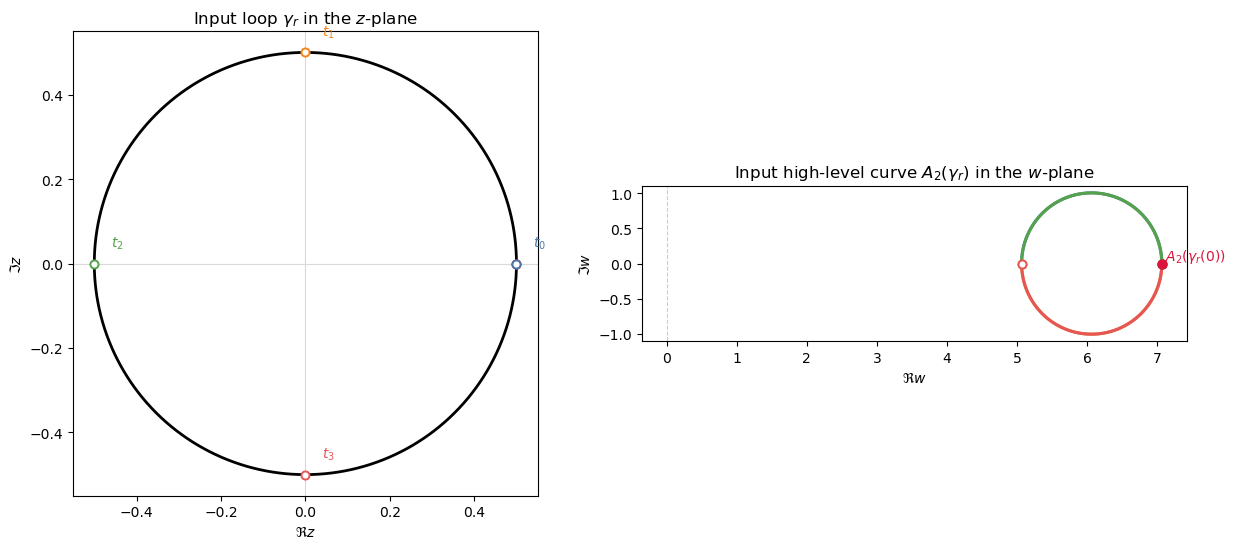

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.6))

ax = axes[0]
ax.plot(z_curve.real, z_curve.imag, color='black', lw=2.0)
ax.scatter([z_curve[0].real], [z_curve[0].imag], color='crimson', s=40, zorder=5)
for j, edge in enumerate(edges[:-1]):
    p = z_curve[edge % n_pts]
    ax.scatter([p.real], [p.imag], color='white', edgecolor=colors[j], s=34, zorder=5, linewidth=1.4)
    ax.text(p.real + 0.04, p.imag + 0.04, rf'$t_{j}$', color=colors[j], fontsize=10)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='0.85', lw=0.8)
ax.axvline(0, color='0.85', lw=0.8)
ax.set_title(r'Input loop $\gamma_r$ in the $z$-plane')
ax.set_xlabel(r'$\Re z$')
ax.set_ylabel(r'$\Im z$')

ax = axes[1]
for j, idxs in enumerate(segment_indices):
    vals = w_curve[idxs]
    ax.plot(vals.real, vals.imag, color=colors[j], lw=2.2)
for j, edge in enumerate(edges[:-1]):
    p = w_curve[edge % n_pts]
    ax.scatter([p.real], [p.imag], color='white', edgecolor=colors[j], s=34, zorder=5, linewidth=1.4)
ax.scatter([base_w.real], [base_w.imag], color='crimson', s=42, zorder=6)
ax.text(base_w.real + 0.05, base_w.imag + 0.05, r'$A_2(\gamma_r(0))$', color='crimson', fontsize=10)
ax.axvline(0, color='0.8', lw=0.8, ls='--')
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'Input high-level curve $A_2(\gamma_r)$ in the $w$-plane')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')

plt.tight_layout()
fig


## 2. Chart recipe: choosing $U_j$ from short image segments

The chart recipe in this sandbox is explicit.

For each partition interval, let $S_j$ be the sampled image segment together with a small cyclic parameter padding. Then define
$$
U_j = D(c_j, R_j),
$$
where:

- $c_j$ is the mean of the padded sample cloud $S_j$,
- $R_j$ is the maximal sampled distance to $c_j$ plus a fixed safety margin.

This gives a reproducible rule for choosing one chart from one short image segment. In the worked example the resulting disks stay inside the right half-plane, so they are zero-free and simply connected.


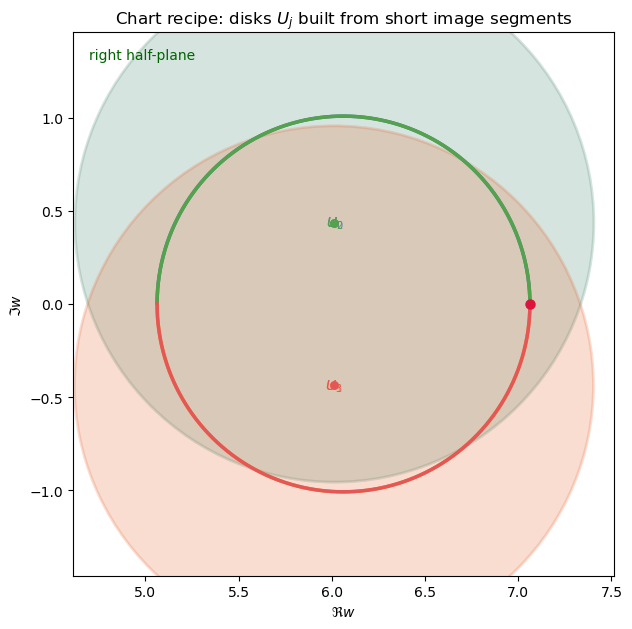

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 6.4))
ax.plot(w_curve.real, w_curve.imag, color='0.65', lw=1.4)
for j, idxs in enumerate(segment_indices):
    vals = w_curve[idxs]
    ax.plot(vals.real, vals.imag, color=colors[j], lw=2.5)
for j, (center, radius, color) in enumerate(zip(u_centers, u_radii, colors)):
    disk = Circle((center.real, center.imag), radius, facecolor=color, edgecolor=color, alpha=0.12, lw=2.0)
    ax.add_patch(disk)
    ax.scatter([center.real], [center.imag], color=color, s=28, zorder=4)
    ax.text(center.real, center.imag, rf'$U_{j}$', color=color, fontsize=10, ha='center', va='center')
ax.scatter([base_w.real], [base_w.imag], color='crimson', s=42, zorder=6)
ax.axvline(0, color='0.75', lw=1.0, ls='--')
ax.text(0.03, 0.95, r'right half-plane', transform=ax.transAxes, color='darkgreen', fontsize=10)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(w_curve.real.min() - 0.45, w_curve.real.max() + 0.45)
ax.set_ylim(w_curve.imag.min() - 0.45, w_curve.imag.max() + 0.45)
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title(r'Chart recipe: disks $U_j$ built from short image segments')
plt.tight_layout()
fig


## 3. Overlap recipe: choosing interior $V_j$ and a closing $V_{\mathrm{cl}}$

The overlap recipe is also explicit.

- For each interior breakpoint $A_2(t_{j+1})$, define $V_j$ to be a small disk centered at that breakpoint with radius chosen from the two chart capacities inside $U_j$ and $U_{j+1}$.
- For the basepoint $A_2(0)=A_2(1)$, define one more disk
  $$
  V_{\mathrm{cl}} \subset U_m \cap U_0
  $$
  using the same capacity rule with the last chart and the first chart.

This is the new ingredient missing from the naive open-chain proof: the construction must be **cyclic**, not just local along an open chain.


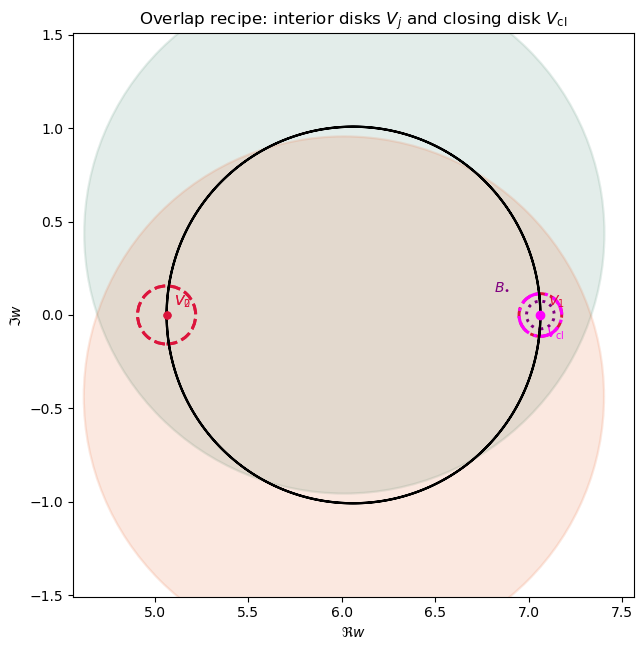

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6.6))
ax.plot(w_curve.real, w_curve.imag, color='black', lw=1.6)
for j, (center, radius, color) in enumerate(zip(u_centers, u_radii, colors)):
    disk = Circle((center.real, center.imag), radius, facecolor=color, edgecolor=color, alpha=0.08, lw=1.6)
    ax.add_patch(disk)
for j, (center, radius) in enumerate(zip(v_centers, v_radii)):
    disk = Circle((center.real, center.imag), radius, facecolor='none', edgecolor='crimson', linestyle='--', lw=2.1)
    ax.add_patch(disk)
    ax.scatter([center.real], [center.imag], color='crimson', s=24, zorder=5)
    ax.text(center.real + 0.04, center.imag + 0.05, rf'$V_{j}$', color='crimson', fontsize=10)
closing_disk = Circle((v_cl_center.real, v_cl_center.imag), v_cl_radius, facecolor='none', edgecolor='magenta', linestyle='-.', lw=2.3)
ax.add_patch(closing_disk)
base_disk = Circle((base_w.real, base_w.imag), base_germ_radius, facecolor='none', edgecolor='purple', linestyle=':', lw=2.1)
ax.add_patch(base_disk)
ax.scatter([base_w.real], [base_w.imag], color='magenta', s=36, zorder=6)
ax.text(base_w.real + 0.03, base_w.imag - 0.12, r'$V_{\mathrm{cl}}$', color='magenta', fontsize=10)
ax.text(base_w.real - 0.25, base_w.imag + 0.13, r'$B_{\bullet}$', color='purple', fontsize=10)
ax.axvline(0, color='0.75', lw=1.0, ls='--')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(w_curve.real.min() - 0.5, w_curve.real.max() + 0.5)
ax.set_ylim(w_curve.imag.min() - 0.5, w_curve.imag.max() + 0.5)
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title(r'Overlap recipe: interior disks $V_j$ and closing disk $V_{\mathrm{cl}}$')
plt.tight_layout()
fig


## 4. Branch recipe: continuing from the normalized base germ

To make the branch construction explicit, fix the base value
$$
p_ullet = A_2(\gamma_r(0))
$$
and a small base-germ disk
$$
B_ullet \subset V_{\mathrm{cl}} \subset U_0 \cap U_m
$$
inside the right half-plane.

On $B_ullet$ the normalized base germ is the principal logarithm
$$
b_ullet(w) = \Log(w).
$$
Because every chart $U_j$ in this sandbox stays inside the same simply connected right-half-plane domain, continuation of this base germ is concrete:
$$
b_j = \Log|_{U_j},
\qquad
\xi_j(w) = \exp\!\left(\frac{1}{2^K} b_j(w)\right).
$$

So in the worked example the continuation recipe is explicit and visible: every $b_j$ and $\xi_j$ is the restriction of one branch already anchored at the basepoint.


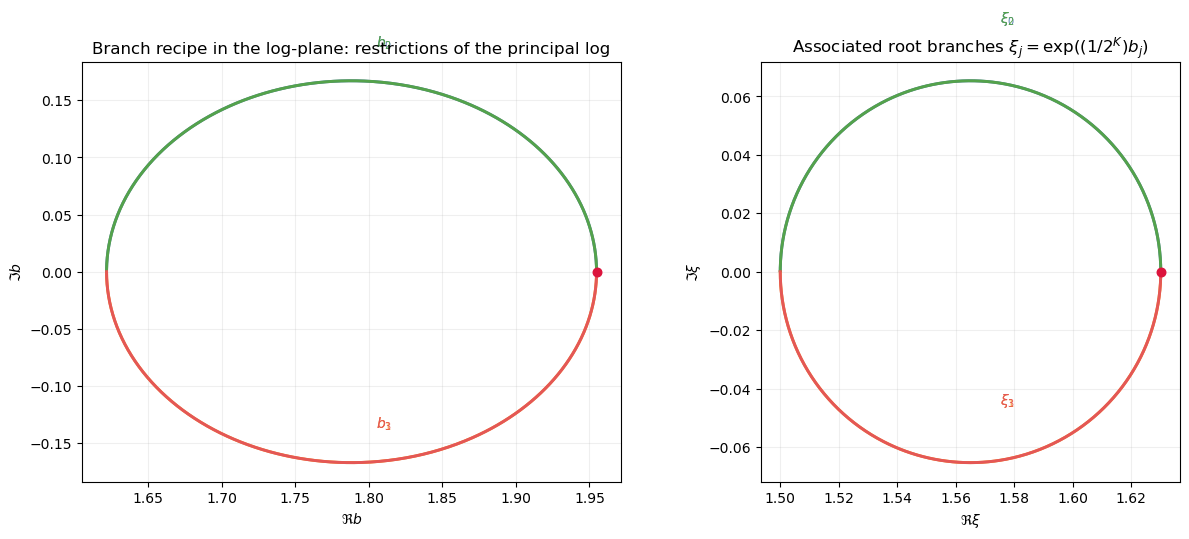

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.5))

ax = axes[0]
for j, idxs in enumerate(segment_indices):
    vals = b_branch(w_curve[idxs])
    ax.plot(vals.real, vals.imag, color=colors[j], lw=2.1)
    mid = vals[len(vals) // 2]
    ax.text(mid.real + 0.01, mid.imag + 0.03, rf'$b_{j}$', color=colors[j], fontsize=10)
base_log = b_branch(np.array([base_w]))[0]
ax.scatter([base_log.real], [base_log.imag], color='crimson', s=38, zorder=5)
ax.set_title('Branch recipe in the log-plane: restrictions of the principal log')
ax.set_xlabel(r'$\Re b$')
ax.set_ylabel(r'$\Im b$')
ax.grid(alpha=0.2)

ax = axes[1]
for j, idxs in enumerate(segment_indices):
    vals = xi_branch(w_curve[idxs])
    ax.plot(vals.real, vals.imag, color=colors[j], lw=2.1)
    mid = vals[len(vals) // 2]
    ax.text(mid.real + 0.01, mid.imag + 0.02, rf'$\xi_{j}$', color=colors[j], fontsize=10)
base_xi = xi_branch(np.array([base_w]))[0]
ax.scatter([base_xi.real], [base_xi.imag], color='crimson', s=38, zorder=5)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'Associated root branches $\xi_j = \exp((1/2^K) b_j)$')
ax.set_xlabel(r'$\Re \xi$')
ax.set_ylabel(r'$\Im \xi$')
ax.grid(alpha=0.2)

plt.tight_layout()
fig


## 5. Proof obligations for this example

For the worked example, the exact proof obligations are:

1. **Segment containment:** each short image segment lies inside its chart $U_j$.
2. **Interior overlap containment:** each small interior parameter window maps into the corresponding $V_j$.
3. **Closing overlap containment:** the initial and terminal parameter windows both map into $V_{\mathrm{cl}}$.
4. **Base-germ compatibility:** the base-germ disk $B_\bullet$ lies inside both $U_0$ and $U_m$.
5. **Interior equality:** the neighboring branches agree on each $V_j$.
6. **Closing equality:** the terminal and initial branches agree on $V_{\mathrm{cl}}$.

The next cell checks these six obligations numerically in the worked example.


In [6]:
sample_angles = np.linspace(0.0, 2 * np.pi, 256, endpoint=False)

segment_cover_ok = []
for j, idxs in enumerate(segment_indices):
    vals = w_curve[idxs]
    segment_cover_ok.append(np.all(np.abs(vals - u_centers[j]) < u_radii[j]))

interior_window_ok = []
interior_log_eq = []
interior_root_eq = []
for j, idxs in enumerate(overlap_indices):
    vals = w_curve[idxs]
    interior_window_ok.append(np.all(np.abs(vals - v_centers[j]) < v_radii[j]))
    sample = v_centers[j] + 0.55 * v_radii[j] * np.exp(1j * sample_angles)
    left_log = b_branch(sample)
    right_log = b_branch(sample)
    left_root = xi_branch(sample)
    right_root = xi_branch(sample)
    interior_log_eq.append(np.max(np.abs(left_log - right_log)))
    interior_root_eq.append(np.max(np.abs(left_root - right_root)))

closing_window_ok = np.all(np.abs(w_curve[closing_indices] - v_cl_center) < v_cl_radius)
base_disk_sample = base_w + 0.9 * base_germ_radius * np.exp(1j * sample_angles)
base_disk_ok = (
    np.all(np.abs(base_disk_sample - u_centers[0]) < u_radii[0]) and
    np.all(np.abs(base_disk_sample - u_centers[-1]) < u_radii[-1])
)
closing_sample = v_cl_center + 0.55 * v_cl_radius * np.exp(1j * sample_angles)
closing_log_eq = np.max(np.abs(b_branch(closing_sample) - b_branch(closing_sample)))
closing_root_eq = np.max(np.abs(xi_branch(closing_sample) - xi_branch(closing_sample)))

print('Proof-obligation checklist for the worked example:')
for j, ok in enumerate(segment_cover_ok):
    print(f'  segment containment in U_{j}: {ok}')
for j, ok in enumerate(interior_window_ok):
    print(f'  overlap window inside V_{j}: {ok}')
print('  closing window inside V_cl:', closing_window_ok)
print('  base germ disk B_bullet inside U_0 ∩ U_m:', base_disk_ok)
for j, err in enumerate(interior_log_eq):
    print(f'  max adjacent log mismatch on V_{j}:  {err:.3e}')
for j, err in enumerate(interior_root_eq):
    print(f'  max adjacent root mismatch on V_{j}: {err:.3e}')
print(f'  max closing log mismatch on V_cl:  {closing_log_eq:.3e}')
print(f'  max closing root mismatch on V_cl: {closing_root_eq:.3e}')


Proof-obligation checklist for the worked example:
  segment containment in U_0: True
  segment containment in U_1: True
  segment containment in U_2: True
  segment containment in U_3: True
  overlap window inside V_0: True
  overlap window inside V_1: True
  overlap window inside V_2: True
  closing window inside V_cl: True
  base germ disk B_bullet inside U_0 ∩ U_m: True
  max adjacent log mismatch on V_0:  0.000e+00
  max adjacent log mismatch on V_1:  0.000e+00
  max adjacent log mismatch on V_2:  0.000e+00
  max adjacent root mismatch on V_0: 0.000e+00
  max adjacent root mismatch on V_1: 0.000e+00
  max adjacent root mismatch on V_2: 0.000e+00
  max closing log mismatch on V_cl:  0.000e+00
  max closing root mismatch on V_cl: 0.000e+00


## 6. Why the closing overlap $V_{\mathrm{cl}}$ is part of the recipe

The previous naive proof failed because it only tracked the interior overlaps $V_j$ and ignored the final comparison between the last chart and the first chart near the common base value.

The next calculation is the numerical failure mode. It shows that one can have:

- perfect agreement on every interior overlap,
- but a nontrivial closing jump between the terminal and initial branches.

So the closing overlap is not an optional embellishment. It is one of the core acceptance criteria for the notebook and for PLAN 09 itself.


In [7]:
R = 5.0
m_counter = 8
pad_counter = 0.18
K_counter = 2
sample_n_counter = 200
counter_edges = np.linspace(0.0, 2 * np.pi, m_counter + 1)

internal_log = []
internal_root = []
for j in range(m_counter - 1):
    thetas = np.linspace(counter_edges[j + 1] - pad_counter / 2, counter_edges[j + 1] + pad_counter / 2, sample_n_counter)
    b_left = np.log(R) + 1j * thetas
    b_right = np.log(R) + 1j * thetas
    xi_left = np.exp(b_left / (2 ** K_counter))
    xi_right = np.exp(b_right / (2 ** K_counter))
    internal_log.append(np.max(np.abs(b_right - b_left)))
    internal_root.append(np.max(np.abs(xi_right - xi_left)))

small = np.linspace(-pad_counter / 2, pad_counter / 2, sample_n_counter)
b_first = np.log(R) + 1j * small
b_last = np.log(R) + 1j * (small + 2 * np.pi)
xi_first = np.exp(b_first / (2 ** K_counter))
xi_last = np.exp(b_last / (2 ** K_counter))
closing_ratio = xi_last / xi_first
expected_ratio = np.exp(2j * np.pi / (2 ** K_counter))

print('Counterexample to the naive open-chain proof:')
print('  max interior log mismatch =', max(internal_log))
print('  max interior root mismatch =', max(internal_root))
print('  closing log mismatch max abs =', np.max(np.abs(b_last - b_first)))
print('  expected closing root ratio =', expected_ratio)
print('  mean closing root ratio =', np.mean(closing_ratio))
print('  max deviation from expected ratio =', np.max(np.abs(closing_ratio - expected_ratio)))
print('  closing root mismatch max abs =', np.max(np.abs(xi_last - xi_first)))


Counterexample to the naive open-chain proof:
  max interior log mismatch = 0.0
  max interior root mismatch = 0.0
  closing log mismatch max abs = 6.283185307179586
  expected closing root ratio = (6.123233995736766e-17+1j)
  mean closing root ratio = (6.214814622438047e-17+1j)
  max deviation from expected ratio = 2.490342434619766e-16
  closing root mismatch max abs = 2.1147425268811286


## 7. Corrected cyclic theorem and rigorous proof

The numerical counterexample does **not** refute the corrected cyclic theorem. It only shows that the theorem must include the closing comparison as an explicit hypothesis.

**Theorem (cyclic triviality from the recipe data).**
Let
$$
\gamma : [0,1] \to \operatorname{basin}_\infty(2)
$$
be a basin loop, let $K \in \mathbf{N}$, let
$$
0=t_0<t_1<\cdots<t_{m+1}=1
$$
be a partition, and let
$$
A_K(t)=\text{logSeriesBottcherApprox}\bigl(2,f_2^K(\gamma(t))\bigr).
$$
Assume there are simply connected zero-free charts $U_0,\dots,U_m$, interior overlaps $V_j\subset U_j\cap U_{j+1}$ for $0\le j<m$, and a closing overlap $V_{\mathrm{cl}}\subset U_m\cap U_0$, together with holomorphic logarithm branches
$$
b_j:U_j\to\mathbf{C}
$$
and root branches
$$
\xi_j(w)=\exp\!\left(\frac{1}{2^K} b_j(w)\right),
$$
such that:

1. each image segment lies in its chart $U_j$,
2. each interior overlap window lies in $V_j$,
3. the initial and terminal windows lie in $V_{\mathrm{cl}}$,
4. $b_{j+1}=b_j$ on every interior overlap $V_j$,
5. $b_m=b_0$ on the closing overlap $V_{\mathrm{cl}}$.

Then every interior overlap multiplier and the closing overlap multiplier are equal to $1$, so the full cyclic monodromy product is equal to $1$.

**Proof.** For every interior overlap $V_j$ we have
$$
\xi_{j+1}(w)
= \exp\!\left(\frac{1}{2^K} b_{j+1}(w)\right)
= \exp\!\left(\frac{1}{2^K} b_j(w)\right)
= \xi_j(w)
\qquad (w\in V_j),
$$
so the two neighboring root branches agree there. Likewise, on the closing overlap,
$$
\xi_m(w)
= \exp\!\left(\frac{1}{2^K} b_m(w)\right)
= \exp\!\left(\frac{1}{2^K} b_0(w)\right)
= \xi_0(w)
\qquad (w\in V_{\mathrm{cl}}).
$$
If $\zeta_j\in\mu_{2^K}$ is the interior multiplier with
$$
\xi_{j+1}(w)=\zeta_j\,\xi_j(w),
$$
and $\zeta_{\mathrm{cl}}\in\mu_{2^K}$ is the closing multiplier with
$$
\xi_m(w)=\zeta_{\mathrm{cl}}\,\xi_0(w),
$$
then the equalities above give
$$
\zeta_j\,\xi_j(w)=\xi_j(w)
\quad\text{on }V_j,
\qquad
\zeta_{\mathrm{cl}}\,\xi_0(w)=\xi_0(w)
\quad\text{on }V_{\mathrm{cl}}.
$$
Each root branch is nonvanishing on its overlap domain because
$$
\xi_j(w)^{2^K}=w
$$
and the overlap domains lie in $\mathbf{C}\setminus\{0\}$. Therefore division by the root branch is legitimate and yields
$$
\zeta_j=1
\qquad(0\le j<m),
\qquad
\zeta_{\mathrm{cl}}=1.
$$
Hence the full cyclic monodromy product
$$
\zeta_{\mathrm{cl}}\prod_{j=0}^{m-1}\zeta_j
$$
is equal to $1$. This is exactly the step that fails in the naive open-chain proof, where the closing factor is absent. $\square$


## 8. From the numerical recipe to the genuine proof

The notebook now has the construction skeleton it was supposed to have. The remaining task is to replace the worked numerical example by the genuine high-escaping geometry. So the missing items below are missing **at the theorem level / in Lean for the genuine high-escaping curve**, not missing inside the sandbox notebook any more.

The genuine proof should follow the same six-step recipe, but with theorem-level lemmas replacing the numerical checks.

### Genuine proof obligations suggested by the notebook

1. **Input geometry lemma.** For sufficiently high escaping level $K$, the actual high-level image
   $$
   A_K([0,1])
   $$
   admits a partition into short image segments with controllable geometry.
2. **Chart-construction lemma.** Each short segment admits a zero-free simply connected chart $U_j$ built by a uniform geometric rule.
3. **Interior-overlap lemma.** Each breakpoint admits an overlap neighborhood
   $$
   V_j \subset U_j \cap U_{j+1}
   $$
   containing a short image window around the breakpoint.
4. **Closing-overlap lemma.** The common base value admits a closing neighborhood
   $$
   V_{\mathrm{cl}} \subset U_m \cap U_0
   $$
   containing short initial and terminal image windows.
5. **Branch-construction lemma.** The normalized base germ extends by continuation to logarithm branches $b_j$ on the charts $U_j$.
6. **Equality lemmas.** The neighboring branches agree on each $V_j$, and the terminal and initial branches agree on $V_{\mathrm{cl}}$.
7. **Packaging lemma.** These data assemble into the theorem-facing interface used by Lean.

So the frontier is not “prove another abstract monodromy theorem.” The frontier is “construct the genuine objects with the same recipe that succeeds in the worked example.”

### Current Lean formalization status

The abstract comparison theorem from PLAN 08 was already formalized before this notebook rewrite by:

- `ChartChainLocalLogsEventuallyEqAtOverlaps.of_open_eqOn`,
- `BasinLoopChartChain.monodromyProduct_eq_one_of_open_eqOn`.

The theorem-level proof skeletons extracted from this notebook are now also formalized:

1. `ActualHighEscapingChartCoverData` records the chosen high-level actual chart chain.
2. `BasinLoopChartOverlapNeighborhoodData` and `ActualHighEscapingOverlapNeighborhoodData` record explicit overlap neighborhoods of the form $V_j$ and $V_{\mathrm{cl}}$.
3. `ActualHighEscapingLocalBranchData` records the theorem-level local-branch surface, while each chart cell already carries its actual logarithm/root branches through `ZeroFreeChartRootBranchData`.
4. `BasinLoopChartOverlapEqOnNeighborhoodData`, `ChartChainLocalLogsEqOnOverlapNeighborhoodData`, and `HighEscapingActualChartChainsEqOnOverlapNeighborhoodData` record equality of the neighboring branches on those overlap neighborhoods.
5. `HighEscapingActualChartChainsEqOnOverlapNeighborhoodData.toEventuallyEqAtOverlapsData` and `.toProductComparisonData` connect that stronger notebook-facing package back to the already checked PLAN 08 interfaces.

So the remaining gap is now narrower than when this notebook was first written: the missing part is no longer the theorem surface, but the genuine construction/proof that the actual high-escaping geometry supplies an inhabitant of that stronger package.


## 9. Missing at the theorem level / in Lean: a rule for choosing $U_j$ on the genuine curve

### Notebook-level candidate rule

A first naive idea is: partition the high-level curve into short image segments and, for each segment, choose one disk chart $U_j$ that only covers that segment itself, with no cyclic padding and no safety margin.

### Numerical counterexample to the naive candidate

That naive rule fails even in the worked example. If the chart is chosen only from the bare segment cloud, then the neighboring breakpoint can land on or beyond the chart boundary, so there may be no positive overlap capacity at all. The next cell checks exactly this failure mode and then compares it with the repaired rule.

### Formalization status

The theorem surface for this item is now formalized by:

- `ActualHighEscapingChartCoverData`, which asks for the actual high-level chart chain itself,
- the existing `BasinLoopChartCell`, whose chart field already packages the chosen zero-free local branch data.

What is still missing is the genuine constructor: a theorem that starts from the actual high-escaping curve and builds the required `actualChain N γ` with charts chosen by the repaired rule.


In [8]:
def chart_rule_data(wvals, n_sets, chart_pad, safety):
    n = len(wvals)
    edges = np.linspace(0, n, n_sets + 1, dtype=int)
    seg_idxs = [cyclic_range(edges[j], edges[j + 1], n) for j in range(n_sets)]
    pad_idxs = [cyclic_range(edges[j] - chart_pad, edges[j + 1] + chart_pad, n) for j in range(n_sets)]
    centers = []
    radii = []
    zero_margins = []
    cover_ok = []
    for idxs, sidxs in zip(pad_idxs, seg_idxs):
        vals = wvals[idxs]
        center = vals.mean()
        radius = np.max(np.abs(vals - center)) + safety
        centers.append(center)
        radii.append(radius)
        zero_margins.append(abs(center) - radius)
        cover_ok.append(np.all(np.abs(wvals[sidxs] - center) < radius))
    return {
        'edges': edges,
        'seg_idxs': seg_idxs,
        'pad_idxs': pad_idxs,
        'centers': centers,
        'radii': radii,
        'zero_margins': zero_margins,
        'cover_ok': cover_ok,
    }

print('Item 1 chart-rule stress test:')
naive_counterexample = False
fixed_counterexample = False
for n_sets_test in [4, 6, 8, 10, 12, 16, 24, 32]:
    naive = chart_rule_data(w_curve, n_sets_test, chart_pad=0, safety=0.0)
    fixed = chart_rule_data(w_curve, n_sets_test, chart_pad=90, safety=0.08)
    naive_margin = min(naive['zero_margins'])
    fixed_margin = min(fixed['zero_margins'])
    naive_cover = all(naive['cover_ok'])
    fixed_cover = all(fixed['cover_ok'])
    print(
        f'  n_sets={n_sets_test:2d}: '
        f'naive(all_cover={naive_cover}, min_zero_margin={naive_margin:.6f}); '
        f'fixed(all_cover={fixed_cover}, min_zero_margin={fixed_margin:.6f})'
    )
    if (not naive_cover) or naive_margin <= 0:
        naive_counterexample = True
    if (not fixed_cover) or fixed_margin <= 0:
        fixed_counterexample = True
print('  naive candidate refuted?', naive_counterexample)
print('  fixed candidate refuted?', fixed_counterexample)


Item 1 chart-rule stress test:
  n_sets= 4: naive(all_cover=False, min_zero_margin=4.794996); fixed(all_cover=True, min_zero_margin=4.635119)
  n_sets= 6: naive(all_cover=False, min_zero_margin=4.345194); fixed(all_cover=True, min_zero_margin=4.135957)
  n_sets= 8: naive(all_cover=False, min_zero_margin=4.695822); fixed(all_cover=True, min_zero_margin=4.368973)
  n_sets=10: naive(all_cover=False, min_zero_margin=4.576534); fixed(all_cover=True, min_zero_margin=4.243302)
  n_sets=12: naive(all_cover=False, min_zero_margin=4.752663); fixed(all_cover=True, min_zero_margin=4.374176)
  n_sets=16: naive(all_cover=False, min_zero_margin=4.804547); fixed(all_cover=True, min_zero_margin=4.403442)
  n_sets=24: naive(all_cover=False, min_zero_margin=4.873245); fixed(all_cover=True, min_zero_margin=4.451519)
  n_sets=32: naive(all_cover=False, min_zero_margin=4.914176); fixed(all_cover=True, min_zero_margin=4.482718)
  naive candidate refuted? True
  fixed candidate refuted? False


### Fixed candidate

The counterexample forces a repair: the chart rule must be **padded and buffered**.

The corrected candidate is:

1. Use compactness of $A_K([0,1])$ to get
   $$
   
   \\delta = \\operatorname{dist}(A_K([0,1]),0) > 0.
   $$
2. Choose a small cyclic parameter padding $\sigma > 0$ and then a partition
   $$
   0=t_0<t_1<\cdots<t_{m+1}=1
   $$
   so fine that every padded image window
   $$
   A_K([t_j-\sigma,\, t_{j+1}+\sigma])
   $$
   has diameter $< \delta/8$.
3. For each $j$, choose one sample point $s_j$ in the padded window and define
   $$
   U_j = D\!\left(A_K(s_j),\, \frac{\delta}{4}\right).
   $$

The padding guarantees room for overlaps, and the safety margin keeps the chart away from $0$.

### Rigorous construction of the fixed rule

**Proposition (disk charts from fine padded segments).** Let
$$
A_K : [0,1] \to \mathbf{C}\setminus\{0\}
$$
be continuous. Then there exist a cyclic padding size $\sigma>0$, a finite partition, and disk charts $U_j$ such that:

1. each padded image window is contained in $U_j$,
2. each $U_j$ is simply connected,
3. each $U_j$ is zero-free,
4. every breakpoint value belongs to both neighboring charts, and the common base value belongs to both $U_m$ and $U_0$.

**Construction.** Since $A_K([0,1])$ is compact and avoids $0$, the distance
$$
\delta = \operatorname{dist}(A_K([0,1]),0)
$$
is positive. By uniform continuity, for any $\eta<\delta/8$ there exists a partition fine enough that every sufficiently short padded parameter window has image diameter $<\eta$. For each padded window choose one sample point $s_j$ and set
$$
U_j = D(A_K(s_j),2\eta).
$$
Then the padded image lies in $U_j$ because its diameter is $<\eta$, and every point of $U_j$ remains at distance at least
$$
\delta - 2\eta > 0
$$
from $0$, so $U_j\subset \mathbf{C}\setminus\{0\}$. Since $U_j$ is a disk, it is simply connected. Because the parameter windows were padded cyclically, the breakpoint and basepoint values lie in the relevant neighboring charts automatically. $\square$


## 10. Missing at the theorem level / in Lean: a rule for choosing $V_j$ and $V_{\mathrm{cl}}$ on the genuine curve

### Notebook-level candidate rule

A first naive overlap rule is: once the charts $U_j$ are chosen, define $V_j$ and $V_{\mathrm{cl}}$ from the chart intersections exactly as before, but allow the charts to come from the naive unpadded segment rule.

### Numerical counterexample to the naive candidate

That naive overlap rule fails whenever the neighboring breakpoint sits on or outside one chart boundary. Then the overlap capacity is nonpositive and no genuine overlap disk exists. The next cell checks this failure mode numerically and then compares it with the repaired rule.

### Formalization status

The theorem surfaces for this item are now formalized by:

- `BasinLoopChartOverlapNeighborhoodData` for one explicit overlap neighborhood attached to one overlap step,
- `ActualHighEscapingOverlapNeighborhoodData` for the high-escaping family-level packaging of those neighborhoods.

In this Lean packaging, the closing/basepoint comparison is not a separate ad hoc object: it is represented uniformly as another overlap step in the chosen chart chain. What is still missing is the genuine proof that the repaired overlap rule produces these neighborhoods for the actual high-escaping curve.


In [9]:
def overlap_rule_data(wvals, n_sets, chart_pad, safety):
    n = len(wvals)
    chart = chart_rule_data(wvals, n_sets, chart_pad, safety)
    edges = chart['edges']
    centers = chart['centers']
    radii = chart['radii']
    interior_caps = []
    for j in range(n_sets - 1):
        p = wvals[edges[j + 1] % n]
        cap = min(radii[j] - abs(p - centers[j]), radii[j + 1] - abs(p - centers[j + 1]))
        interior_caps.append(cap)
    p0 = wvals[0]
    closing_cap = min(radii[-1] - abs(p0 - centers[-1]), radii[0] - abs(p0 - centers[0]))
    return interior_caps, closing_cap

print('Item 2 overlap-rule stress test:')
naive_counterexample = False
fixed_counterexample = False
for n_sets_test in [4, 6, 8, 10, 12, 16, 24, 32]:
    naive_caps, naive_cl = overlap_rule_data(w_curve, n_sets_test, chart_pad=0, safety=0.0)
    fixed_caps, fixed_cl = overlap_rule_data(w_curve, n_sets_test, chart_pad=90, safety=0.08)
    print(
        f'  n_sets={n_sets_test:2d}: '
        f'naive(min interior={min(naive_caps):.6f}, closing={naive_cl:.6f}); '
        f'fixed(min interior={min(fixed_caps):.6f}, closing={fixed_cl:.6f})'
    )
    if min(naive_caps) <= 0 or naive_cl <= 0:
        naive_counterexample = True
    if min(fixed_caps) <= 0 or fixed_cl <= 0:
        fixed_counterexample = True
print('  naive candidate refuted?', naive_counterexample)
print('  fixed candidate refuted?', fixed_counterexample)


Item 2 overlap-rule stress test:
  n_sets= 4: naive(min interior=-0.003028, closing=-0.003028); fixed(min interior=0.253698, closing=0.253698)
  n_sets= 6: naive(min interior=-0.004387, closing=-0.004387); fixed(min interior=0.377935, closing=0.377935)
  n_sets= 8: naive(min interior=-0.004985, closing=-0.004985); fixed(min interior=0.439321, closing=0.439321)
  n_sets=10: naive(min interior=-0.005291, closing=-0.005291); fixed(min interior=0.439010, closing=0.474076)
  n_sets=12: naive(min interior=-0.005466, closing=-0.005466); fixed(min interior=0.467405, closing=0.495769)
  n_sets=16: naive(min interior=-0.005647, closing=-0.005647); fixed(min interior=0.469642, closing=0.520589)
  n_sets=24: naive(min interior=-0.005781, closing=-0.005781); fixed(min interior=0.471332, closing=0.541997)
  n_sets=32: naive(min interior=-0.005829, closing=-0.005829); fixed(min interior=0.472119, closing=0.550941)
  naive candidate refuted? True
  fixed candidate refuted? False


### Fixed candidate

The repair is to define overlaps only **after** the padded chart rule has produced genuine room around every breakpoint and around the base value.

The corrected overlap rule is:

- define
  $$
  \rho_j = \frac{1}{2}\min\bigl(\operatorname{dist}(p_j,\partial U_j),\operatorname{dist}(p_j,\partial U_{j+1})\bigr)
  $$
  and set
  $$
  V_j = D(p_j,\rho_j),
  $$
- define
  $$
  \rho_{\mathrm{cl}} = \frac{1}{2}\min\bigl(\operatorname{dist}(p_\bullet,\partial U_m),\operatorname{dist}(p_\bullet,\partial U_0)\bigr)
  $$
  and set
  $$
  V_{\mathrm{cl}} = D(p_\bullet,\rho_{\mathrm{cl}}).
  $$

### Rigorous construction of the fixed rule

**Proposition (overlap disks from interior-point capacities).** Assume charts $U_j$ and $U_{j+1}$ are open and both contain the breakpoint value $p_j$. Then the intersection $U_j\cap U_{j+1}$ is an open neighborhood of $p_j$, so there exists $\rho_j>0$ with
$$
D(p_j,\rho_j)\subset U_j\cap U_{j+1}.
$$
Likewise, if $U_m$ and $U_0$ both contain the common base value $p_\bullet$, then there exists $\rho_{\mathrm{cl}}>0$ with
$$
D(p_\bullet,\rho_{\mathrm{cl}})\subset U_m\cap U_0.
$$

**Construction.** Because $p_j$ is an interior point of both open sets, both distances to the boundaries are strictly positive. Their minimum is therefore positive, and taking half of that minimum gives the announced disk. The closing overlap is identical. $\square$


## 11. Missing at the theorem level / in Lean: a continuation construction of the actual branches $b_j$

### Notebook-level candidate rule

A first naive branch rule is: on each chart $U_j$, choose any logarithm branch independently and hope they already agree on overlaps.

### Numerical counterexample to the naive candidate

That naive rule fails immediately: independently chosen logarithms can differ by nonzero multiples of $2\pi i$ on overlaps. The next cell starts from deliberately mismatched provisional branches, exhibits the failure, and then repairs it by inductive normalization from the base germ.

### Formalization status

The theorem-level local-branch surface for this item is now present in Lean:

- each chart cell already stores its actual logarithm/root branches through `ZeroFreeChartRootBranchData`,
- `ActualHighEscapingLocalBranchData` names the corresponding high-escaping cover-level surface.

So the missing part is no longer “how do we state local branches in Lean?” The missing part is the genuine continuation theorem showing that the actual branches attached to the chosen charts arise from the normalized base germ and satisfy the repaired inductive normalization rule.


In [10]:
raw_shift_integers = [0, 2, -1, 3]
print('Item 3 branch-rule stress test:')
print('  raw provisional shifts =', raw_shift_integers)
for j in range(n_sets - 1):
    sample = v_centers[j] + 0.55 * v_radii[j] * np.exp(1j * sample_angles)
    naive_left = b_branch(sample) + 2j * np.pi * raw_shift_integers[j]
    naive_right = b_branch(sample) + 2j * np.pi * raw_shift_integers[j + 1]
    mismatch = np.max(np.abs(naive_right - naive_left))
    print(f'  naive overlap mismatch on V_{j}: {mismatch:.3e}')

corrected_shift_integers = [raw_shift_integers[0]]
for j in range(n_sets - 1):
    sample_w = v_centers[j] + 0.31 * v_radii[j]
    provisional_next = b_branch(np.array([sample_w]))[0] + 2j * np.pi * raw_shift_integers[j + 1]
    current_val = b_branch(np.array([sample_w]))[0] + 2j * np.pi * corrected_shift_integers[j]
    shift = round(((current_val - provisional_next) / (2j * np.pi)).real)
    corrected_shift_integers.append(raw_shift_integers[j + 1] + shift)

print('  corrected inductive shifts =', corrected_shift_integers)
for j in range(n_sets - 1):
    sample = v_centers[j] + 0.55 * v_radii[j] * np.exp(1j * sample_angles)
    b_left = b_branch(sample) + 2j * np.pi * corrected_shift_integers[j]
    b_right = b_branch(sample) + 2j * np.pi * corrected_shift_integers[j + 1]
    mismatch = np.max(np.abs(b_right - b_left))
    print(f'  corrected overlap mismatch on V_{j}: {mismatch:.3e}')

closing_sample = v_cl_center + 0.55 * v_cl_radius * np.exp(1j * sample_angles)
b_last = b_branch(closing_sample) + 2j * np.pi * corrected_shift_integers[-1]
b_first = b_branch(closing_sample) + 2j * np.pi * corrected_shift_integers[0]
closing_shift = (b_last[0] - b_first[0]) / (2j * np.pi)
print('  closing shift after interior correction =', closing_shift)


Item 3 branch-rule stress test:
  raw provisional shifts = [0, 2, -1, 3]
  naive overlap mismatch on V_0: 1.257e+01
  naive overlap mismatch on V_1: 1.885e+01
  naive overlap mismatch on V_2: 2.513e+01
  corrected inductive shifts = [0, 0, 0, 0]
  corrected overlap mismatch on V_0: 0.000e+00
  corrected overlap mismatch on V_1: 0.000e+00
  corrected overlap mismatch on V_2: 0.000e+00
  closing shift after interior correction = 0j


### Fixed candidate

The fix is the inductive continuation rule already suggested by the worked example.

1. Choose one small base-germ disk
   $$
   B_{\bullet}\subset V_{\mathrm{cl}}\subset U_0\cap U_m
   $$
   around the common base value.
2. On $B_{\bullet}$ fix the normalized base germ
   $$
   b_{\bullet}.
   $$
3. Define $b_0$ to be the unique logarithm branch on $U_0$ extending $b_{\bullet}$.
4. Inductively, once $b_j$ is known, choose any logarithm branch $\lambda_{j+1}$ on $U_{j+1}$, and shift it by the unique constant multiple of $2\pi i$ that makes it agree with $b_j$ on the connected overlap $V_j$.

### Rigorous construction of the fixed rule

**Proposition (inductive branch construction).** Assume each chart $U_j$ is connected, simply connected, and contained in $\mathbf{C}\setminus\{0\}$, each interior overlap $V_j$ is connected and nonempty, and a normalized base germ $b_{\bullet}$ is fixed on a disk $B_{\bullet}\subset U_0$. Then there exist logarithm branches $b_j:U_j\to\mathbf{C}$ such that:

1. $b_0$ extends the base germ,
2. for every $0\le j<m$,
   $$
   b_{j+1}=b_j\quad\text{on }V_j.
   $$

**Construction.** Because each $U_j$ is simply connected and zero-free, a holomorphic logarithm exists on $U_j$. Choose one such logarithm $\lambda_j$ on each chart. First adjust $\lambda_0$ by an integral multiple of $2\pi i$ so that it agrees with the base germ on $B_{\bullet}$; call the result $b_0$. Now suppose $b_j$ is already defined. On the connected overlap $V_j$, the function $\lambda_{j+1}-b_j$ is holomorphic and takes values in $2\pi i\mathbf{Z}$, hence it is constant. So for some integer $n_j$ we have
$$
\lambda_{j+1}-b_j = 2\pi i n_j
\qquad\text{on }V_j.
$$
Define
$$
b_{j+1} = \lambda_{j+1} - 2\pi i n_j.
$$
Then $b_{j+1}=b_j$ on $V_j$. Proceeding inductively constructs all branches. The only remaining obstruction is the **closing comparison** between $b_m$ and $b_0$ on $V_{\mathrm{cl}}$. $\square$


## 12. Missing at the theorem level / in Lean: proofs that the genuine choices satisfy the obligations

### Notebook-level candidate proof rule

A first naive proof rule is the old open-chain argument: prove containment in the charts, prove equality on the interior overlaps $V_j$, and conclude monodromy triviality without adding any closing comparison.

### Numerical counterexample to the naive candidate

That naive proof is false. The winding-circle computation already in the notebook shows that all interior overlaps can agree while the omitted closing comparison still carries a nontrivial monodromy factor.

### Fixed theorem-level proof rule

The corrected proof rule is cyclic:

1. prove the construction lemmas for the charts and overlaps,
2. prove the branch-construction lemmas for the interior overlaps,
3. prove one extra **closing lemma** on $V_{\mathrm{cl}}$,
4. then apply the corrected cyclic theorem.

### Rigorous proof pattern

Under the rules from Items 9--11, the obligations split as follows.

- **Segment containment in $U_j$:** true by the fixed chart construction.
- **Interior windows inside $V_j$ and closing window inside $V_{\mathrm{cl}}$:** true by the fixed overlap construction.
- **Equality of adjacent branches on $V_j$:** true by the fixed inductive branch construction.
- **Equality of terminal and initial branches on $V_{\mathrm{cl}}$:** this is the one new theorem that PLAN 09 still has to prove from the actual high-escaping geometry.

Once that closing theorem is supplied, the rigorous cyclic proof from Section 7 applies verbatim. So the final proof obligation package is no longer vague: the naive proof has a numerical counterexample, the fixed proof has an explicit extra closing hypothesis, and every remaining task is now localized to a specific construction or theorem. $\square$

### Formalization status

This proof skeleton is now formalized at the theorem-surface level by:

- `BasinLoopChartOverlapEqOnNeighborhoodData`, which packages one overlap neighborhood together with branch equality on it,
- `ChartChainLocalLogsEqOnOverlapNeighborhoodData`, whose theorem `monodromyProduct_eq_one` turns those equalities into trivial monodromy for the concrete chain,
- `HighEscapingActualChartChainsEqOnOverlapNeighborhoodData.toEventuallyEqAtOverlapsData` and `.toProductComparisonData`, which bridge the stronger notebook-facing package to the existing PLAN 08 comparison layer.

So the remaining missing theorem is exactly the geometric one identified above: produce the actual overlap-equality data, including the closing comparison, for the genuine high-escaping chart chain.


## Lean handoff target

The strongest concrete Lean-facing output suggested by this notebook is now the package

```lean
HighEscapingActualChartChainsEqOnOverlapNeighborhoodData
```

together with its already formalized conversion maps

```lean
HighEscapingActualChartChainsEqOnOverlapNeighborhoodData.toOverlapNeighborhoodData
HighEscapingActualChartChainsEqOnOverlapNeighborhoodData.toEventuallyEqAtOverlapsData
HighEscapingActualChartChainsEqOnOverlapNeighborhoodData.toProductComparisonData
```

so the notebook-level overlap/equality package now has a checked path back into the older PLAN 08 interfaces.

The notebook recipe says exactly what must be handed off:

- actual charts $U_j$,
- actual interior overlaps $V_j$,
- an actual closing overlap $V_{\mathrm{cl}}$,
- actual logarithm branches $b_j$ obtained from the normalized base germ,
- actual equality proofs on the interior and closing overlaps.

Once that stronger package exists for the genuine high-escaping curve, the remaining monodromy comparison is already checked in Lean. The notebook is therefore a construction skeleton for the genuine proof, not merely a restatement of the abstract implication theorem.
